JSON data type: <class 'dict'>
Total records: 12643
Keys of first record: ['filename', 'class', 'tumor_type', 'sequence', 'width', 'height', 'point', 'location', 'has_lesion', 'bbox_path', 'mask_path', 'file_name']
First record (abbreviated):
  filename: T1 - Medulloblastoma - cerebellopontine angle brainstem 001....
  class: Medulloblastoma T1
  tumor_type: Medulloblastoma
  sequence: T1
  width: 512
  height: 512
  point: {'x': 289.0, 'y': 298.0}
  location: ['brainstem']
  has_lesion: 1
  bbox_path: Embryonic Tumors/Embryonic Tumors T1/Medulloblastoma T1/T1 -...
  mask_path: Embryonic Tumors/Embryonic Tumors T1/Medulloblastoma T1/T1 -...
  file_name: Embryonic Tumors/Embryonic Tumors T1/Medulloblastoma T1/T1 -...

Available columns: ['filename', 'class', 'tumor_type', 'sequence', 'width', 'height', 'point', 'location', 'has_lesion', 'bbox_path', 'mask_path', 'file_name']
Using column 'class' as target.
First 10 target values:
 0    Medulloblastoma T1
1    Medulloblastoma T1
2    Med

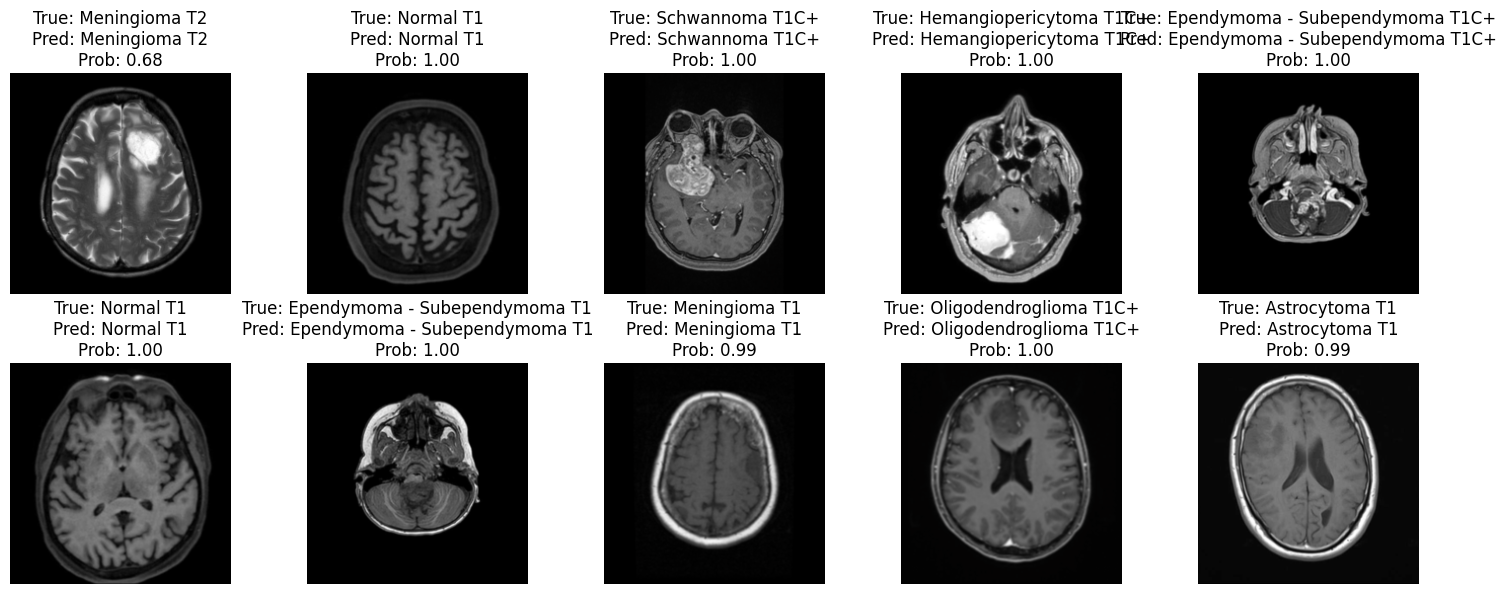

Visualization saved as 'test_predictions.png'


In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ----------------------------- Configuration -----------------------------------
DATA_JSON = "/kaggle/input/datasets/fernando2rad/brain-tumor-12k-mri-images-w-masks-meta-and-bbox/DATA.json"
BASE_IMG_DIR = "/kaggle/input/datasets/fernando2rad/brain-tumor-12k-mri-images-w-masks-meta-and-bbox/Images_/Images_/"
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42
TEST_SIZE = 0.1
VAL_SIZE = 0.1
NUM_VISUALIZE = 10                 

# ----------------------------- Load JSON (dictionary) --------------------------
with open(DATA_JSON, 'r') as f:
    raw = json.load(f)

print("JSON data type:", type(raw))

if not isinstance(raw, dict):
    raise TypeError(f"Expected dict, got {type(raw)}")

# Convert dict to list of records 
records = []
for filename, meta in raw.items():
    record = meta.copy()
    record['file_name'] = filename
    records.append(record)

print("Total records:", len(records))
if len(records) == 0:
    raise ValueError("No records found in JSON")

# Show structure of first record 
print("Keys of first record:", list(records[0].keys()))
print("First record (abbreviated):")
for k, v in records[0].items():
    if isinstance(v, str) and len(v) > 60:
        print(f"  {k}: {v[:60]}...")
    else:
        print(f"  {k}: {v}")

# Create DataFrame
df = pd.DataFrame(records)

# ----------------------------- Determine columns ------------------------------
print("\nAvailable columns:", df.columns.tolist())

# Find a column for class labels
possible_class_cols = ['class', 'tumor_type', 'label', 'diagnosis', 'type']
class_col = None
for col in possible_class_cols:
    if col in df.columns:
        class_col = col
        break

if class_col is None:
    # Try to combine tumor_type + sequence 
    if 'tumor_type' in df.columns and 'sequence' in df.columns:
        print("Column 'class' not found. Creating combination of tumor_type + sequence")
        df['class'] = df['tumor_type'].astype(str) + ' ' + df['sequence'].astype(str)
        class_col = 'class'
    else:
        print("ERROR: No suitable class column found. Available:", df.columns.tolist())
        raise KeyError("No class column")

print(f"Using column '{class_col}' as target.")
print("First 10 target values:\n", df[class_col].head(10))
print("Class distribution (top 10):\n", df[class_col].value_counts().head(10))

# Encode labels 
if df[class_col].dtype == object:
    label_encoder = LabelEncoder()
    df['label'] = label_encoder.fit_transform(df[class_col])
    num_classes = len(label_encoder.classes_)
    print(f"Number of unique classes: {num_classes}")
else:
    df['label'] = df[class_col]
    num_classes = df['label'].nunique()
    label_encoder = None

# Column with filename
file_col = 'file_name'
print(f"Using column '{file_col}' for image paths.")

# Build full image path
df['image_path'] = df[file_col].apply(lambda x: os.path.join(BASE_IMG_DIR, x))

# Check first few paths
print("\nFirst 3 image paths (and existence):")
for i, p in enumerate(df['image_path'].head(3)):
    exists = os.path.exists(p)
    print(f"{i+1}: {p} -> {exists}")
    if not exists:
        # Try using the key directly 
        alt_path = os.path.join(BASE_IMG_DIR, os.path.basename(p))
        print(f"   Alternative (basename): {alt_path} -> {os.path.exists(alt_path)}")

# Using the key 
sample_key = list(raw.keys())[0]
if os.path.exists(os.path.join(BASE_IMG_DIR, sample_key)):
    print("\nFiles are accessible via full path: e.g.", os.path.join(BASE_IMG_DIR, sample_key))
else:
    # Check if the key itself is a valid relative path
    if os.path.exists(sample_key):
        print(f"File accessible without BASE_IMG_DIR: {sample_key}")
        df['image_path'] = df[file_col]   
    else:
        print("WARNING: Could not locate image files. Please check path structure.")

# ----------------------------- Train/Val/Test Split ----------------------------
X = df['image_path'].values
y = df['label'].values

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=VAL_SIZE/(1-TEST_SIZE),
    stratify=y_train_val, random_state=RANDOM_SEED
)

print(f"\nSplit sizes: Train {len(X_train)}, Val {len(X_val)}, Test {len(X_test)}")

# ----------------------------- Dataset Class -----------------------------------
class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            # Fallback: black image if file missing
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform:
            image = self.transform(image)
        return image, label

# ----------------------------- Transforms --------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----------------------------- DataLoaders -------------------------------------
train_dataset = BrainTumorDataset(X_train, y_train, transform=train_transform)
val_dataset = BrainTumorDataset(X_val, y_val, transform=val_transform)
test_dataset = BrainTumorDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

# ----------------------------- Model Definition --------------------------------
def get_model(num_classes):
    model = models.resnet50(pretrained=True)
    # Freeze all layers except layer4 and fc
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = get_model(num_classes).to(DEVICE)

# Class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ----------------------------- Training Functions ------------------------------
def train_one_epoch(loader, model, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

def evaluate(loader, model, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels

# ----------------------------- Training Loop -----------------------------------
best_val_acc = 0.0
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(train_loader, model, optimizer, criterion)
    val_loss, val_acc, _, _ = evaluate(val_loader, model, criterion)
    scheduler.step(val_loss)
    print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# ----------------------------- Test Evaluation --------------------------------
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc, test_preds, test_labels = evaluate(test_loader, model, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
if label_encoder is not None:
    target_names = label_encoder.classes_
else:
    target_names = [str(i) for i in range(num_classes)]
print(classification_report(test_labels, test_preds, target_names=target_names))

# ----------------------------- Visualization of 10 Random Test Images ----------
def visualize_predictions(model, dataset, label_encoder, num_images=10, device='cuda'):
    """
    Randomly select images from the dataset, predict, and display with true/pred labels.
    """
    model.eval()
    indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))
    
    # Prepare subplot grid
    cols = 5
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    axes = axes.flatten() if rows > 1 else [axes]  # handle single row

    # Denormalization function for display
    def denormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        return tensor * std + mean   # clip later

    for i, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]
        # Move to device and add batch dimension
        img_tensor = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(img_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            pred_prob, pred_label = torch.max(probabilities, dim=1)
        
        pred_label = pred_label.item()
        true_label = true_label.item()
        pred_prob = pred_prob.item()
        
        # Convert image tensor to displayable format
        img_display = denormalize(img_tensor.squeeze(0).cpu())
        img_display = torch.clamp(img_display, 0, 1)
        img_display = img_display.permute(1,2,0).numpy()
        
        # Get class names
        if label_encoder is not None:
            true_name = label_encoder.classes_[true_label]
            pred_name = label_encoder.classes_[pred_label]
        else:
            true_name = str(true_label)
            pred_name = str(pred_label)
        
        ax = axes[i]
        ax.imshow(img_display)
        ax.set_title(f"True: {true_name}\nPred: {pred_name}\nProb: {pred_prob:.2f}")
        ax.axis('off')
    
    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Visualization saved as 'test_predictions.png'")

# Run visualization on the test dataset
visualize_predictions(
    model=model,
    dataset=test_dataset,
    label_encoder=label_encoder,
    num_images=NUM_VISUALIZE,
    device=DEVICE
)